In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exploring the Association Between Obesity and Depression: A Cross-Country Analysis


## Introduction

Depression is one of the leading causes of disability worldwide, affecting an estimated **332 million people** according to the [World Health Organization](https://www.who.int/news-room/fact-sheets/detail/depression). It is still widely assumed that depression is primarily a psychological condition - something rooted in thoughts, mindset, or life circumstances. However, growing research suggests that the picture is far more complex.

Evidence points to a physiological component involving the dysregulation of three interconnected biological systems ([Vinkers et al.,2021](https://pubmed.ncbi.nlm.nih.gov/33549878/)):
- The **hypothalamic-pituitary-adrenal (HPA) axis**, which governs the stress response
- The **immune system**, where chronic low-grade inflammation has been linked to depressive episodes ([Berk et al., 2013](https://doi.org/10.1186/1741-7015-11-200))
- The **autonomic nervous system (ANS)**, which regulates involuntary physiological functions

One underexplored factor in this biological pathway is diet. Poor nutrition can drive systemic inflammation, disrupt gut microbiota, and impair neurotransmitter synthesis - all mechanisms with plausible links to depression. A 2017 meta-analysis published in *Psychosomatic Medicine* found that a healthy diet was associated with a significantly reduced risk of depression ([Li et al., 2017](https://doi.org/10.1016/j.psychres.2017.04.020)).

Because country-level dietary quality data is difficult to obtain consistently, this project uses obesity rates as a proxy for poor nutrition. Obesity is strongly associated with diets high in ultra-processed foods, refined sugars, and low in micronutrients - the same dietary patterns implicated in depression risk 
([Gómez-Donoso et al., 2020](https://doi.org/10.3390/nu14132568)).

This project investigates whether obesity rates correlate with depression rates across countries, using publicly available global health data.

## Hypothesis

Since obesity is strongly associated with poor dietary habits ([Afshin et al., 2019](https://doi.org/10.1016/S0140-6736(19)30041-8)), we use it as a country-level proxy for nutritional quality.

**H1:** Countries with higher obesity rates will show higher rates of depressive disorders.

We will test this both as a **cross-country snapshot** (comparing countries at a single point in time) and as a **within-country trend** (examining whether changes in obesity within a country co-occur with changes in depression over time).

## Data

We use two datasets: 

1. **Mental Health Data** - prevalence of depressive disorders as a share of population, age-standardized, across countries and years [Kaggle](https://www.kaggle.com/datasets/imtkaggleteam/mental-health?select=1-+mental-illnesses-prevalence.csv).
2. **Obesity Data** - share of adults with BMI ≥ 25 (overweight/obese), age-standardized, across countries and years [Our World in Data](https://ourworldindata.org/grapher/share-of-adults-who-are-overweight).

BMI (Body Mass Index) is calculated as:
$$
\mathrm{BMI} = \frac{m}{h^2}
$$
where $m$ is mass in kilograms and $h$ is height in metres. A BMI of 25 or above is classified as overweight by the [WHO](https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight).

### Loading the Data

In [22]:
mental_health = pd.read_csv('mental-health-data/mental-illnesses-prevalence.csv')
obesity = pd.read_csv('obesity-data/share-of-adults-who-are-overweight.csv')

In [23]:
print('Mental health dataset:')
print(f'  Rows: {mental_health.shape[0]}, Columns: {mental_health.shape[1]}')
print(f'  Years: {mental_health.Year.min()}–{mental_health.Year.max()}')
print(f'  Entities: {mental_health.Entity.nunique()}')
print()
print('Obesity dataset:')
print(f'  Rows: {obesity.shape[0]}, Columns: {obesity.shape[1]}')
print(f'  Years: {obesity.Year.min()}–{obesity.Year.max()}')
print(f'  Entities: {obesity.Entity.nunique()}')

Mental health dataset:
  Rows: 6420, Columns: 8
  Years: 1990–2019
  Entities: 214

Obesity dataset:
  Rows: 6798, Columns: 4
  Years: 1990–2022
  Entities: 206


### Merging & Cleaning

The two datasets differ in the number of entities (countries, regions, aggregates) they cover. To ensure we only work with rows that exist in both datasets, we perform an inner merge on `Entity` and `Year`. This automatically drops any country-year combinations that appear in only one of the datasets.

In [24]:
# Merge both tables on Entity and Year (inner join - keeps only shared country-year pairs)
obesity_mental_health_df = pd.merge(mental_health, obesity, on=['Entity', 'Year'])

After merging, we reduce the table to only the columns relevant to our analysis and rename them for readability. We will also keep the anxiety column - we will use it later to compare whether the obesity-anxiety relationship differs from the obesity-depression one.

In [25]:
# Reduce to relevant columns only
obesity_mental_health_df = obesity_mental_health_df[[
    "Entity",
    "Year",
    "Depressive disorders (share of population) - Sex: Both - Age: Age-standardized",
    "Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized",
    "Prevalence of overweight among adults, BMI >= 25 (age-standardized estimate) (%) - Sex: both sexes - Age group: 18+  years of age"
]]

In [26]:
# Rename columns for readability
obesity_mental_health_df = obesity_mental_health_df.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Depressive disorders (share of population) - Sex: Both - Age: Age-standardized": "depressive_disorders",
    "Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized": "anxiety_disorders",
    "Prevalence of overweight among adults, BMI >= 25 (age-standardized estimate) (%) - Sex: both sexes - Age group: 18+  years of age": "obesity_rate"
})

### Exploratory Overview
Before starting the analysis, we take a quick look at the merged dataset to understand its shape, value ranges, and whether anything looks unexpected.

In [27]:
# Checking for missing countries since they must be 206 after the merge
print(f'Merged dataset: {obesity_mental_health_df.shape[0]} rows, {obesity_mental_health_df.country.nunique()} entities')

Merged dataset: 5970 rows, 199 entities


In [28]:
missing_from_obesity = set(obesity.Entity.unique()) - set(obesity_mental_health_df.country.unique())
missing_from_mental_health = set(mental_health.Entity.unique()) - set(obesity_mental_health_df.country.unique())

print(f'Entities in obesity data not in merged dataset ({len(missing_from_obesity)}):')
print(missing_from_obesity)
print()
print(f'Entities in mental health data not in merged dataset ({len(missing_from_mental_health)}):')
print(missing_from_mental_health)

Entities in obesity data not in merged dataset (7):
{'French Polynesia', 'South-East Asia (WHO)', 'Americas (WHO)', 'Western Pacific (WHO)', 'Eastern Mediterranean (WHO)', 'Europe (WHO)', 'Africa (WHO)'}

Entities in mental health data not in merged dataset (15):
{'Asia (IHME GBD)', 'United States Virgin Islands', 'Taiwan', 'Europe (IHME GBD)', 'Monaco', 'Low-income countries', 'Africa (IHME GBD)', 'America (IHME GBD)', 'European Union (27)', 'Guam', 'Northern Mariana Islands', 'Upper-middle-income countries', 'High-income countries', 'San Marino', 'Lower-middle-income countries'}


The dropped entries appear to be regional aggregates (such as "Europe (WHO)" or "High-income countries") and small territories. We note their absence but do not investigate further as the focus of this project is on individual countries.

In [29]:
obesity_mental_health_df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,5970.0,2004.500000,8.656166,1990.000000,1997.000000,2004.500000,2012.000000,2019.000000
depressive_disorders,5970.0,3.780257,0.944505,1.522333,3.066551,3.655919,4.389562,7.645899
anxiety_disorders,5970.0,4.087335,1.067037,1.879996,3.416398,3.932944,4.521156,8.624634
obesity_rate,5970.0,42.927505,19.704198,2.817660,26.453363,46.536270,55.506020,91.284530


A few things stand out from the summary statistics:

- Depression rates range from 1.5% to 7.6% and anxiety from 1.9% to 8.6% - both show variation across countries, which is a basis for a cross-country comparison.
- Obesity rates range from 2.8% to 91.3% - the upper end appears extreme and may reflect countries with atypical population characteristics. Investigating and potentially excluding these outliers is noted as a limitation of this analysis.
- The year range spans 1990 to 2019, giving us almost three decades of data.

## Analysis

We approach the hypothesis from two angles:
1. **Within-country examination** - when obesity rises inside a country over time, does depression follow?
2. **Cross-country examination** - do countries with higher obesity tend to have higher depression rates?


### Part 1: Within-Country Examination

**When obesity increases within a specific country over time, does depression also increase?** This approach controls for country-level fixed factors (culture, healthcare, reporting norms) by looking only at *changes* within each country year-over-year.

We compute year-over-year differences for both obesity and depression for each country using `.diff()` grouped by country.

In [30]:
obesity_change = obesity_mental_health_df.groupby("country")["obesity_rate"].diff()
depression_change = obesity_mental_health_df.groupby("country")["depressive_disorders"].diff()

print(f"Obesity change vs. Depression change: {obesity_change.corr(depression_change):.3f}")

Obesity change vs. Depression change: 0.047


The year-over-year change correlation is essentially flat - near zero. Depression rates are stable within individual countries over time, meaning there is very little signal for year-over-year analysis to detect.

The plot below is the average for all countries and illustrates this:

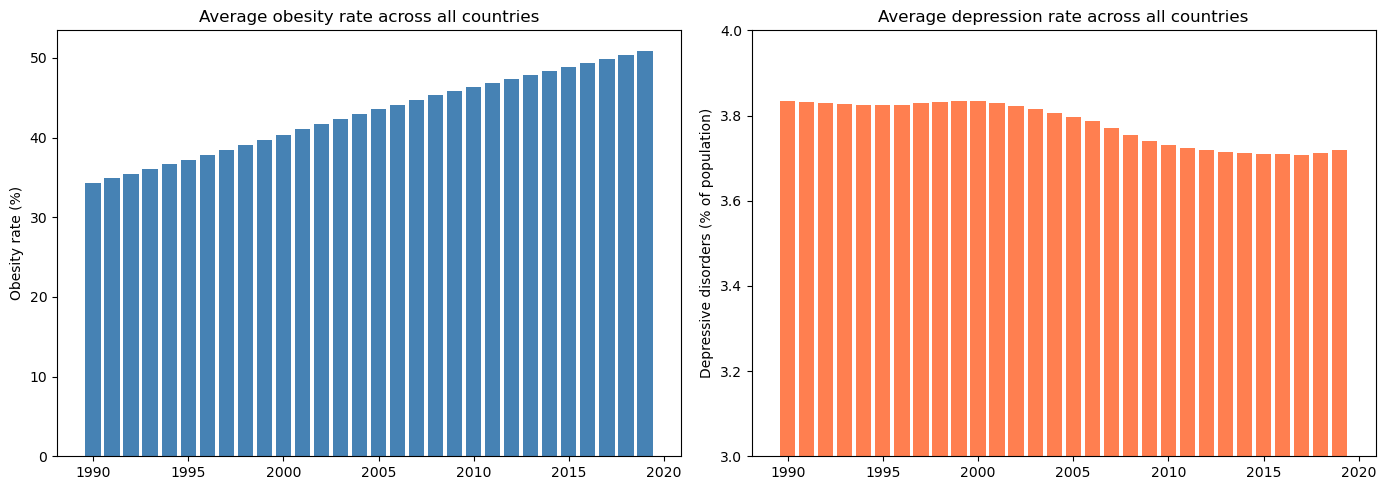

In [31]:
yearly_avg = obesity_mental_health_df.groupby("year")[
    ["obesity_rate", "depressive_disorders"]
].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(yearly_avg.index, yearly_avg["obesity_rate"], color="steelblue")
ax1.set_title("Average obesity rate across all countries")
ax1.set_ylabel("Obesity rate (%)")

ax2.bar(yearly_avg.index, yearly_avg["depressive_disorders"], color="coral")
ax2.set_title("Average depression rate across all countries")
ax2.set_ylabel("Depressive disorders (% of population)")
ax2.set_ylim(3.0, 4.0)

plt.tight_layout()
plt.show()

While obesity rises steadily, depression rates remain almost completely flat within the countries over the same period.

The near-zero correlation suggests that year-over-year changes in obesity within a country are not accompanied by measurable changes in depression over the same period.

### Part 2: Cross-Country Examination

We start by looking at a single year snapshot - 2019 - to compare countries at the same point in time. 2019 is simply the last year in the dataset, so it gives us the most countries with complete data.

We use Pearson correlation and a regression plot to assess the direction and strength of the relationship.

In [32]:
obesity_depression_2019 = obesity_mental_health_df[obesity_mental_health_df["year"] == 2019]

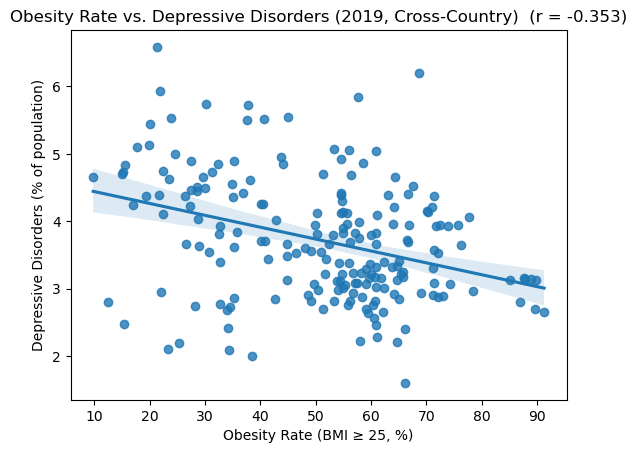

In [33]:
# Pearson correlation between obesity rate and depression rate (2019)
r = obesity_depression_2019['obesity_rate'].corr(obesity_depression_2019['depressive_disorders'])

sns.regplot(data=obesity_depression_2019, x="obesity_rate", y="depressive_disorders")
plt.title(f"Obesity Rate vs. Depressive Disorders (2019, Cross-Country)  (r = {r:.3f})")
plt.xlabel("Obesity Rate (BMI ≥ 25, %)")
plt.ylabel("Depressive Disorders (% of population)")
plt.show()

A **weak negative association** is observed between obesity and depression across countries. This is a counterintuitive result - it suggests that at the country level, higher obesity does not straightforwardly correspond to higher depression. 

This is likely influenced by confounding variables such as economic development, healthcare access, reporting quality and other health variables contributing to depression.

#### Segmentation Analysis

Looking at the regression plot, there appears to be a slight structural difference between countries with lower vs. higher obesity rates - the variability in depression rates is higher at lower obesity levels. We split the data at the 45% obesity rate threshold to examine whether the relationship behaves differently in each group.

In [34]:
low = obesity_depression_2019[obesity_depression_2019["obesity_rate"] < 45]
high = obesity_depression_2019[obesity_depression_2019["obesity_rate"] >= 45]

print("Depression correlation:")
print(f"  Low obesity group:  {low['obesity_rate'].corr(low['depressive_disorders']):.3f}")
print(f"  High obesity group: {high['obesity_rate'].corr(high['depressive_disorders']):.3f}")

Depression correlation:
  Low obesity group:  -0.138
  High obesity group: -0.128


Neither subgroup shows a meaningful correlation, and the direction does not change. 
The overall -0.353 was not a real signal to begin with. The segmentation simply 
confirms the absence of a relationship at every level of the data.

#### High-Income Countries

The global cross-country analysis produced a weak and inconsistent result. One likely reason is that we are mixing countries where fundamentally different mechanisms drive depression:

- **Low-income countries** - depression is more likely driven by nutrient scarcity, food insecurity, and limited healthcare access.
- **High-income countries** - food scarcity is not the issue. The concern is the opposite: diets high in processed foods and refined ingredients despite adequate calories.

Our hypothesis is specifically about the second mechanism. We therefore restrict the analysis to a group of high-income countries where dietary excess - rather than deficiency - is the dominant nutritional reality, and where depression is measured and reported in a comparable way across the group.

In [35]:
high_income_countries = [
    'Australia', 'Austria', 'Belgium', 'Canada', 'Denmark',
    'Finland', 'France', 'Germany', 'Ireland', 'Italy',
    'Japan', 'Netherlands', 'New Zealand', 'Norway', 'Portugal',
    'Spain', 'Sweden', 'Switzerland', 'United Kingdom', 'United States'
]

high_income_df = obesity_mental_health_df[obesity_mental_health_df['country'].isin(high_income_countries)]
print(f'Countries included: {high_income_df["country"].nunique()}')
print(f'Year range: {high_income_df["year"].min()} to {high_income_df ["year"].max()}')

Countries included: 20
Year range: 1990 to 2019


In [36]:
# Average each country across all years
high_income_avg  = high_income_df.groupby('country')[['obesity_rate', 'depressive_disorders']].mean().reset_index()

We average both variables across all available years per country. Since depression rates are structurally stable over time - as shown in Part 1 - this does not distort the depression signal, while averaging obesity produces a more robust country-level estimate than picking any single year.

In [37]:
# Plots a regression scatter with country labels and correlation in the title

def plot_corr(df, x, y, title, ax, ylabel='Average Depressive Disorders (%)'):
    sns.regplot(data=df, x=x, y=y, ax=ax)
    for _, row in df.iterrows():
        ax.annotate(row['country'], (row[x], row[y]),
                    fontsize=7, alpha=0.8, xytext=(4, 2), textcoords='offset points')
    r = df[x].corr(df[y])
    ax.set_title(f'{title}  (r = {r:.3f})')
    ax.set_xlabel('Average Obesity Rate (BMI ≥ 25, %)')
    ax.set_ylabel(ylabel)

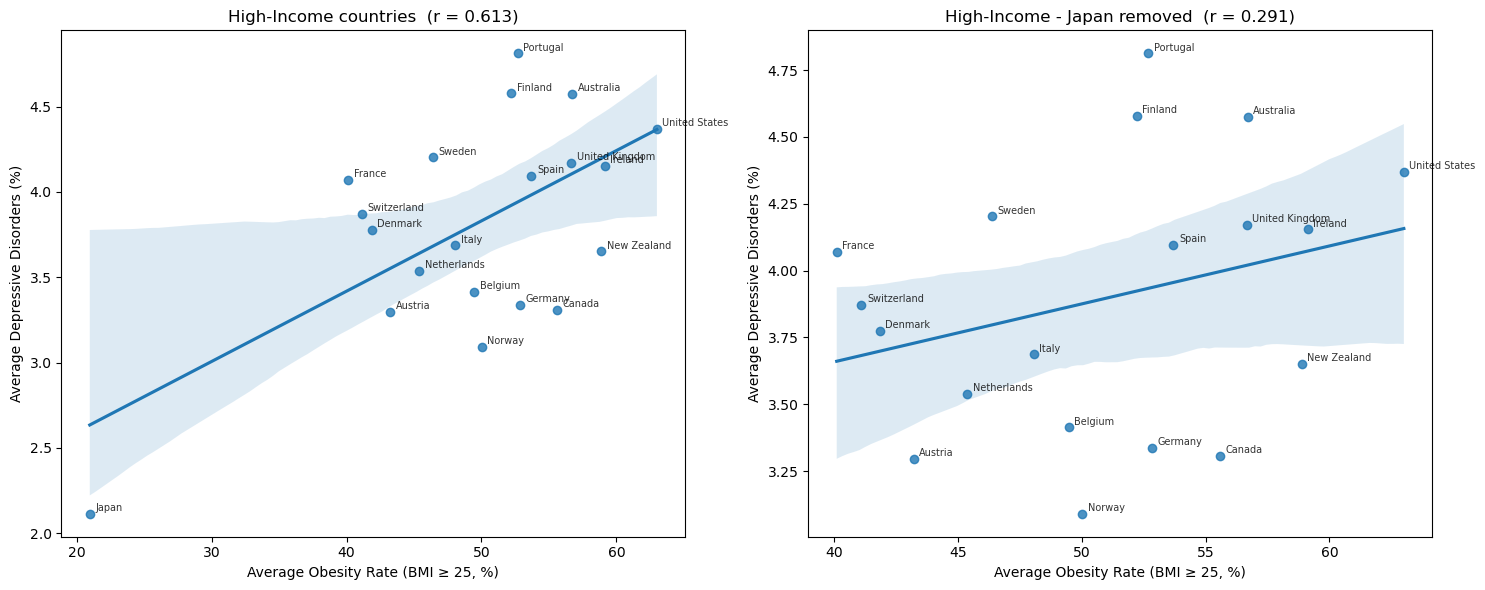

In [38]:
# Left plot: all High-Income countries
# Right plot: same but with Japan removed to test how much it influences the result
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plot_corr(high_income_avg, 'obesity_rate', 'depressive_disorders', 'High-Income countries', ax1)
plot_corr(high_income_avg[high_income_avg['country'] != 'Japan'], 'obesity_rate', 'depressive_disorders', 'High-Income - Japan removed', ax2)
plt.tight_layout()
plt.show()

Japan sits at the low-depression end of the plot, but this is misleading. Japan has one of the highest suicide rates among high-income countries ([WPR](https://worldpopulationreview.com/country-rankings/suicide-rate-by-country)) despite very low reported depression - well-documented cultural phenomenon where mental illness carries strong stigma and is routinely underdiagnosed ([Hori et al. (2019)](https://pmc.ncbi.nlm.nih.gov/articles/PMC6778451/)). This gives us reason to treat Japan's data point with caution.

Removing Japan drops the correlation substantially, suggesting the result depends heavily on a single country whose data we have reason to question.

#### Obesity vs. Depression by Continent
To broaden the picture beyond high-income countries, we map all countries to their continent and examine the relationship within each region separately.

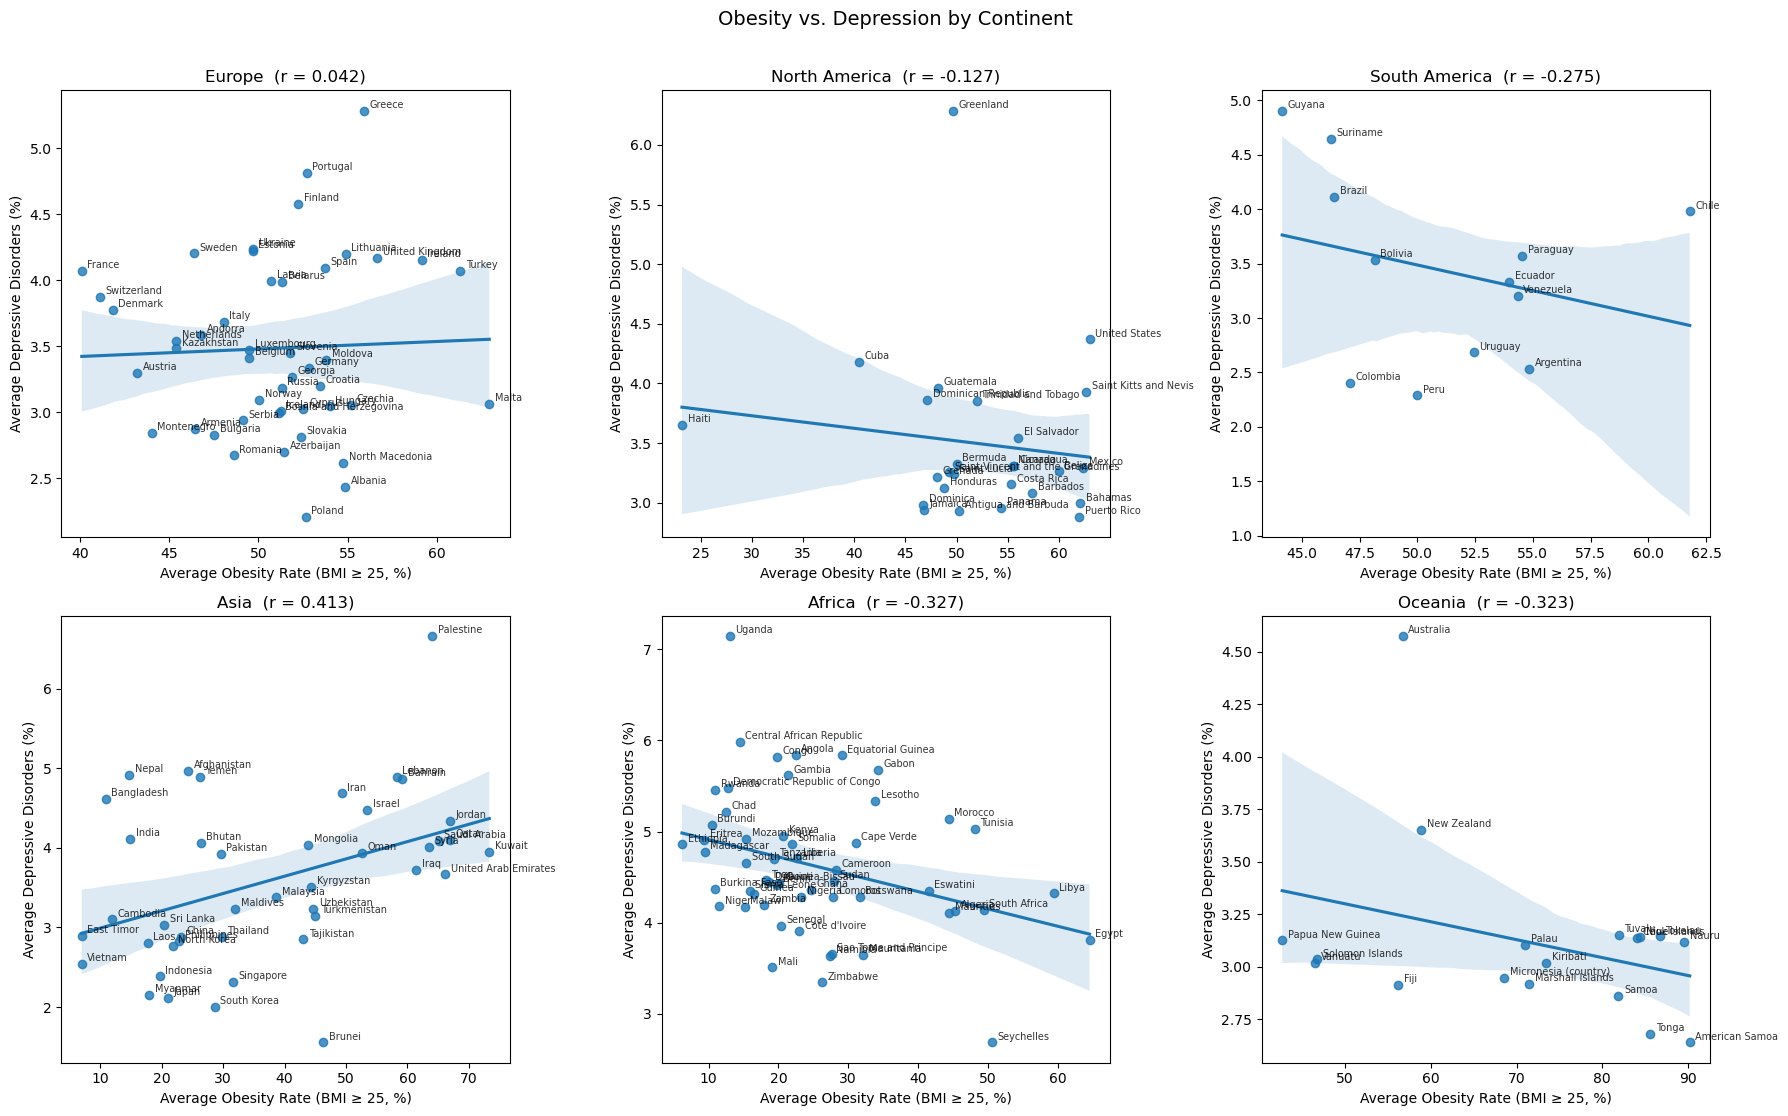

In [39]:
country_avg = obesity_mental_health_df.groupby('country')[['obesity_rate', 'depressive_disorders']].mean().reset_index()

continent_map = {
    'Europe': [
        'Germany', 'France', 'Italy', 'Spain', 'Portugal', 'Netherlands',
        'Belgium', 'Sweden', 'Norway', 'Denmark', 'Finland', 'Austria',
        'Switzerland', 'Ireland', 'Poland', 'Greece', 'Hungary', 'Czechia',
        'Albania', 'Andorra', 'Armenia', 'Azerbaijan', 'Belarus', 'Bosnia and Herzegovina',
        'Bulgaria', 'Croatia', 'Cyprus', 'Estonia', 'Georgia', 'Iceland',
        'Kazakhstan', 'Kosovo', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta',
        'Moldova', 'Montenegro', 'North Macedonia', 'Romania', 'Russia',
        'Serbia', 'Slovakia', 'Slovenia', 'Turkey', 'Ukraine', 'United Kingdom'
    ],
    'North America': [
        'United States', 'Canada', 'Mexico', 'Bahamas', 'Barbados', 'Belize',
        'Bermuda', 'Costa Rica', 'Cuba', 'Dominica', 'Dominican Republic',
        'El Salvador', 'Grenada', 'Guatemala', 'Haiti', 'Honduras', 'Jamaica',
        'Nicaragua', 'Panama', 'Puerto Rico', 'Saint Kitts and Nevis',
        'Saint Lucia', 'Saint Vincent and the Grenadines', 'Trinidad and Tobago',
        'Antigua and Barbuda', 'Greenland'
    ],
    'South America': [
        'Brazil', 'Argentina', 'Chile', 'Colombia', 'Bolivia', 'Ecuador',
        'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela'
    ],
    'Asia': [
        'Japan', 'South Korea', 'China', 'India', 'Israel', 'Afghanistan',
        'Bahrain', 'Bangladesh', 'Bhutan', 'Brunei', 'Cambodia', 'East Timor',
        'Indonesia', 'Iran', 'Iraq', 'Jordan', 'Kuwait', 'Kyrgyzstan', 'Laos',
        'Lebanon', 'Malaysia', 'Maldives', 'Mongolia', 'Myanmar', 'Nepal',
        'North Korea', 'Oman', 'Pakistan', 'Palestine', 'Philippines', 'Qatar',
        'Saudi Arabia', 'Singapore', 'Sri Lanka', 'Syria', 'Tajikistan',
        'Thailand', 'Turkmenistan', 'United Arab Emirates', 'Uzbekistan',
        'Vietnam', 'Yemen'
    ],
    'Africa': [
        'South Africa', 'Nigeria', 'Ethiopia', 'Egypt', 'Algeria', 'Angola',
        'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Cape Verde',
        'Central African Republic', 'Chad', 'Comoros', 'Congo',
        'Democratic Republic of Congo', "Cote d'Ivoire", 'Djibouti',
        'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Gabon', 'Gambia', 'Ghana',
        'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho', 'Liberia', 'Libya',
        'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco',
        'Mozambique', 'Namibia', 'Niger', 'Rwanda', 'Sao Tome and Principe',
        'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Sudan',
        'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'
    ],
    'Oceania': [
        'Australia', 'New Zealand', 'American Samoa', 'Cook Islands', 'Fiji',
        'Kiribati', 'Marshall Islands', 'Micronesia (country)', 'Nauru', 'Niue',
        'Palau', 'Papua New Guinea', 'Samoa', 'Solomon Islands', 'Tokelau',
        'Tonga', 'Tuvalu', 'Vanuatu'
    ]
}

country_avg['continent'] = country_avg['country'].map(
    {c: cont for cont, countries in continent_map.items() for c in countries}
)

continents = list(continent_map.keys())
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, continent in zip(axes, continents):
    subset = country_avg[country_avg['continent'] == continent].dropna(subset=['obesity_rate', 'depressive_disorders'])
    if len(subset) < 3:
        ax.set_visible(False)
        continue
    plot_corr(subset, 'obesity_rate', 'depressive_disorders', continent, ax)

plt.suptitle('Obesity vs. Depression by Continent', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

The continent-level breakdown reveals that the obesity–depression relationship is not consistent across regions. No continent shows a strong, uniform positive correlation in line with H1. There is no need to explore any of the continents further.

### Part 3: Anxiety as a Comparison

To assess whether the obesity–depression pattern is specific to depression or reflects a more general relationship between obesity and mental health, we repeat the continent-level analysis using anxiety 
disorder prevalence instead of depression.

In [40]:
country_avg_anxiety = obesity_mental_health_df.groupby('country')[['obesity_rate', 'anxiety_disorders']].mean().reset_index()

country_avg_anxiety['continent'] = country_avg_anxiety['country'].map(
    {c: cont for cont, countries in continent_map.items() for c in countries}
)

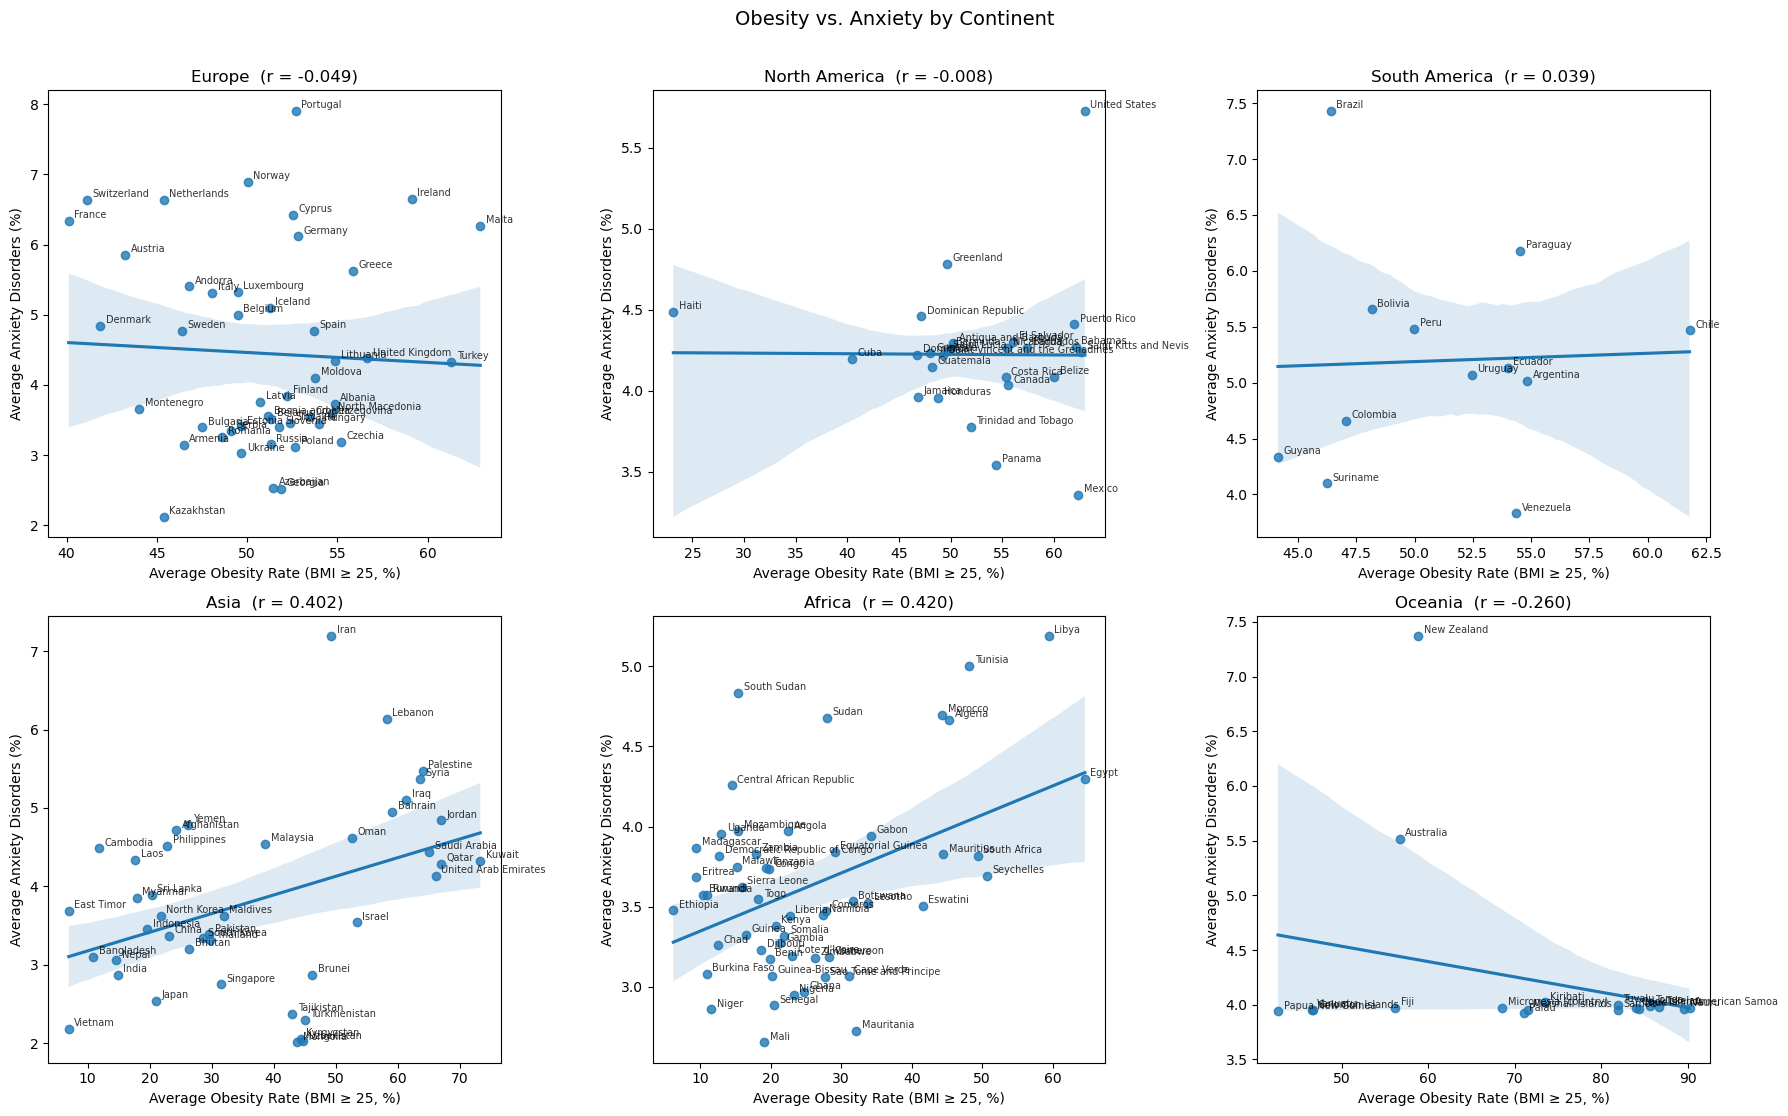

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, continent in zip(axes, continents):
    subset = country_avg_anxiety[country_avg_anxiety['continent'] == continent].dropna(subset=['obesity_rate', 'anxiety_disorders'])
    if len(subset) < 3:
        ax.set_visible(False)
        continue
    plot_corr(subset, 'obesity_rate', 'anxiety_disorders', continent, ax, ylabel='Average Anxiety Disorders (%)')

plt.suptitle('Obesity vs. Anxiety by Continent', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

The results are essentially flat across all continents, with the exception of Asia and Africa which warrant further exploration.

## Conclusion
This project set out to test whether country-level obesity rates - used as a proxy for poor dietary quality - are associated with higher rates of depressive disorders.

The **within-country analysis** (Part 1) found no meaningful relationship: year-over-year changes in obesity within a country are not accompanied by detectable changes in depression. Depression rates are structurally stable at the country level, making this data too coarse for within-country temporal analysis.

The **global cross-country analysis** (Part 2) produced a weak negative correlation - the opposite of H1. Segmentation confirmed there was no real signal at any level of the data. The continent-level breakdown reinforced this: no region showed a meaningful positive correlation.

When **restricted to high-income countries**, a directional positive correlation emerged, consistent with H1. However, this result is sensitive to the inclusion of Japan, whose depression data is known to be unreliable due to cultural underreporting. After removing Japan, the correlation drops substantially.

The continent-level **anxiety analysis** shows no consistent pattern, suggesting the depression result 
is not simply a general artifact of how countries cluster geographically.

**Overall, we find no robust evidence supporting H1.** The hypothesis is not confirmed at the global level. A directional signal exists within high-income countries, but it is fragile and sensitive to a single data point. Stronger conclusions would require finer-grained data - ideally individual-level dietary intake records paired with clinical depression assessments, rather than country-level aggregates.

## Limitations

**1. BMI is an imperfect measure of obesity**  
BMI is a simple weight-to-height ratio that does not account for body composition, fat distribution, age, sex, or metabolic health. A person with a BMI of 30 may have excellent metabolic markers, while a person with a BMI of 22 may carry significant visceral fat. Tomiyama et al. (2016) found that nearly half of individuals classified as overweight by BMI were metabolically healthy, and around 30% of normal-weight individuals were metabolically unhealthy ([Tomiyama et al., 2016](https://doi.org/10.1038/ijo.2016.17)). This means our primary variable is a noisy measure of the construct we care about.

**2. Obesity is an imperfect proxy for dietary quality**  
Even if BMI measured adiposity perfectly, adiposity does not fully capture diet quality. A person eating a highly processed, nutritionally deficient diet may maintain a normal BMI through caloric restriction. The dietary mechanisms hypothesized to drive depression (chronic inflammation, micronutrient deficiency, gut microbiome disruption) can be present in normal-weight individuals consuming poor-quality diets. A randomised controlled trial by Jacka et al. (2017) demonstrated that dietary improvement reduced depressive symptoms independently of weight change, suggesting that diet quality and obesity are separable constructs with respect to depression ([Jacka et al., 2017](https://doi.org/10.1186/s12916-017-0791-y)). Our proxy therefore misses an important segment of the population relevant to our hypothesis.

**3. Country-level data and the ecological fallacy**  
All correlations in this analysis are computed at the country level. A correlation between country averages does not imply the same relationship holds at the individual level. A country with high average obesity and high average depression does not mean that the obese individuals within that country are the ones who are depressed. Drawing individual-level conclusions from aggregate data is known as the ecological fallacy.

**4. Confounding factors**  
Depression is influenced by a wide range of factors beyond diet, including genetics, early-life adversity, socioeconomic conditions, social support, physical activity, and cultural norms around emotional expression. Country-level obesity rates capture very little of this variance, and our analysis cannot isolate the effect of obesity (or the diet it proxies) from these confounders.

**5. Reporting and measurement bias**  
Depression prevalence estimates vary in reliability across countries. As the Japan case illustrates, cultural stigma around mental illness leads to systematic underreporting in some populations. This introduces noise that is difficult to correct for without individual-level clinical data.

**6. Extreme obesity values**  
Obesity rates up to 91.3% appear in the dataset, likely reflecting small Pacific island nations with atypical demographic profiles. These values were not excluded and may exert disproportionate influence on global correlation estimates.

## Resources

- WHO - Depression fact sheet: https://www.who.int/news-room/fact-sheets/detail/depression
- WHO - Obesity and overweight: https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight
- Vinkers et al. (2021) - An integrated approach to understand biological stress system dysregulation across depressive and anxiety disorders: https://pubmed.ncbi.nlm.nih.gov/33549878/
- Berk et al. (2013) - So depression is an inflammatory disease, but where does the inflammation come from? https://doi.org/10.1186/1741-7015-11-200
- Li et al. (2017) - Dietary patterns and depression risk: A meta-analysis : https://doi.org/10.1016/j.psychres.2017.04.020
- Gómez-Donoso et al., (2020) - Ultra-Processed Food Consumption and Mental Health: A Systematic Review and Meta-Analysis of Observational Studies https://doi.org/10.3390/nu14132568
- Afshin et al. (2019) - Health effects of dietary risks in 195 countries: https://doi.org/10.1016/S0140-6736(19)30041-8
- Wikipedia - BMI: https://en.wikipedia.org/wiki/Body_mass_index
- pandas documentation - Merging: https://pandas.pydata.org/pandas-docs/stable/user_guide/merging.html
- Our World in Data - Mental Health: https://ourworldindata.org/mental-health
- Our World in Data - Obesity: https://ourworldindata.org/obesity
- World Population Review - https://worldpopulationreview.com/country-rankings/suicide-rate-by-country
- Hori et al. (2019) - Assessment of current clinical practices for major depression in Japan: https://pmc.ncbi.nlm.nih.gov/articles/PMC6778451/
- Tomiyama et al. (2016) - Misclassification of cardiometabolic health when using body mass index categories in NHANES 2005–2012: https://doi.org/10.1038/ijo.2016.17
- Jacka et al. (2017) - A randomised controlled trial of dietary improvement for adults with major depression (the ‘SMILES’ trial): https://doi.org/10.1186/s12916-017-0791-y